# Clase 1 · Fundamentos de la ciencia de datos

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniopitz/diplomado-cdd/blob/main/01_intro_ecosistema_colab.ipynb)

Esta es la versión para **Google Colab**: las librerías ya vienen instaladas, así que no hay nada que configurar. Si prefiere trabajar en su propio computador, use el notebook `01_intro_ecosistema.ipynb` del repositorio, con el entorno de la guía de instalación.

En esta primera sesión vamos a comprobar que el entorno funciona y a explorar de verdad un conjunto de datos real: la Encuesta Origen Destino de Santiago 2012 (EOD). La exploración sigue el hilo de la clase: cada columna de una tabla es una variable de cierto tipo, y el tipo define qué análisis es válido.

## 1. Verificación del entorno

Si esta celda corre sin errores y muestra las versiones, está todo en orden.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("NumPy      ", np.__version__)
print("Pandas     ", pd.__version__)
print("Matplotlib ", matplotlib.__version__)

NumPy       2.5.2
Pandas      3.0.5
Matplotlib  3.11.1


## 2. NumPy: cálculo sobre arreglos completos

NumPy aporta el arreglo (`array`): una colección de números sobre la que las operaciones se aplican completas, sin escribir ciclos. A eso se le llama vectorización, y es la base de todo el ecosistema: Pandas y Matplotlib trabajan sobre arreglos de NumPy.

Estos cinco valores son duraciones de viaje, en minutos:

In [2]:
tiempos = np.array([70, 105, 90, 25, 40])

print("Media:  ", tiempos.mean(), "minutos")
print("Máximo: ", tiempos.max(), "minutos")
print("En horas:", tiempos / 60)

Media:   66.0 minutos
Máximo:  105 minutos
En horas: [1.16666667 1.75       1.5        0.41666667 0.66666667]


La división `tiempos / 60` se aplicó a los cinco valores de una vez. Con cinco números da lo mismo; con los cientos de miles de filas de una encuesta, la diferencia de velocidad y de claridad del código es considerable.

## 3. Pandas: abrir una tabla real

Pandas aporta el `DataFrame`: una tabla con columnas etiquetadas, cada una de su propio tipo. Vamos a abrir la tabla de viajes de la EOD 2012 directo desde una URL.

Dos detalles del archivo: los campos van separados por punto y coma (`sep=";"`) y los decimales usan coma (`decimal=","`). El archivo pesa unos 15 MB, así que la descarga puede tomar algunos segundos.

In [3]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/cienciadatos/"
    "main/datos/eod_stgo/"
)
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)

viajes.shape

(113591, 35)

113.591 filas: una por viaje registrado. Las tres miradas iniciales a cualquier tabla nueva son `shape` (dimensiones), `head` (primeras filas) e `info` (columnas, tipos y valores presentes).

In [4]:
viajes[["Hogar", "Persona", "ComunaOrigen", "ComunaDestino", "TiempoViaje"]].head()

,Hogar,Persona,ComunaOrigen,ComunaDestino,TiempoViaje
0,173431,17343102,94.0,94.0,70.0
1,173441,17344101,94.0,71.0,105.0
2,173441,17344101,71.0,94.0,90.0
3,173441,17344103,94.0,91.0,55.0
4,173441,17344103,91.0,94.0,150.0


In [5]:
viajes.info(max_cols=15)

<class 'pandas.DataFrame'>
RangeIndex: 113591 entries, 0 to 113590
Columns: 35 entries, Hogar to CodigoTiempo
dtypes: float64(22), int64(9), str(4)
memory usage: 30.3 MB


## 4. Variables cualitativas: contar, no promediar

`ComunaOrigen` guarda números (94, 71, 13...), pero la variable es **nominal**: cada número es un código de comuna. Promediar códigos no significa nada; contar viajes por código, sí. Para variables cualitativas, la herramienta básica es `value_counts`.

In [6]:
# Las 10 comunas de origen con más viajes registrados (códigos, por ahora)
viajes["ComunaOrigen"].value_counts().head(10)

ComunaOrigen
70.0     10283
94.0      8074
100.0     7762
71.0      6442
93.0      5641
72.0      5408
98.0      5376
91.0      3919
82.0      3549
79.0      3379
Name: count, dtype: int64

### Traducir códigos: la primera unión de tablas (`merge`)

Los códigos no se leen solos: la encuesta trae tablas de parámetros que los traducen. La de comunas es una tabla chica con dos columnas, `Id` y `Comuna`:

In [7]:
comunas = pd.read_csv(BASE + "tablas_parametros/Comunas.csv", sep=",")
comunas.head()

,Id,Comuna
0,10,Calama
1,13,Copiapó
2,19,La Serena
3,21,Coquimbo
4,25,Ovalle


Para ponerle nombre a cada viaje se usa `merge`: toma dos tablas y empareja sus filas por una columna común. Aquí, el `ComunaOrigen` de cada viaje se empareja con el `Id` de la tabla de comunas, y cada fila de viajes queda con su columna `Comuna` a la vista. Es la operación con que se navega cualquier base relacional, y la usaremos durante todo el módulo.

In [8]:
viajes_comuna = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id")

# El mismo conteo de recién, ahora legible
viajes_comuna["Comuna"].value_counts().head(10)

Comuna
Santiago        10283
Maipú            8074
Puente Alto      7762
Las Condes       6442
La Florida       5641
Providencia      5408
San Bernardo     5376
Ñuñoa            3919
Pudahuel         3549
Quilicura        3379
Name: count, dtype: int64

El mismo mecanismo, dos veces seguidas, traduce el modo de transporte: `ViajesDifusion.csv` conecta cada viaje con un código de modo, y `ModoDifusion.csv` le pone nombre a ese código.

In [9]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

viajes_modo = (viajes
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID"))

# Proporción de viajes por modo, en la muestra
viajes_modo["NombreModo"].value_counts(normalize=True).round(3)

NombreModo
Caminata                0.298
Bip!                    0.284
Auto                    0.233
Otros                   0.075
Bicicleta               0.034
Taxi Colectivo          0.031
Bip! - Otros Publico    0.021
Taxi                    0.015
Bip! - Otros Privado    0.010
Name: proportion, dtype: float64

La caminata encabeza el reparto, como vimos en la clase. El número no es idéntico al 33,9% de las slides: aquí contamos viajes **de la muestra**, sin aplicar los factores de expansión que convierten la muestra en ciudad. ¿De quién habla cada número? El de la slide, de Santiago; este, de los encuestados. La diferencia entre ambos es el tema de las clases 2 y 3.

Una variable cualitativa también se grafica contando. El mismo reparto, como gráfico de barras:

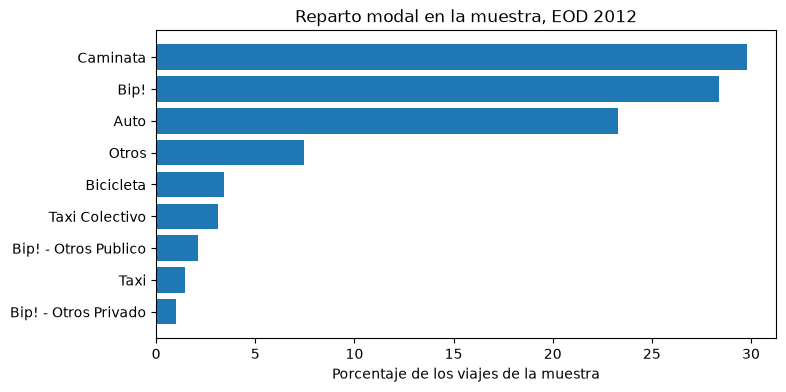

In [10]:
reparto = viajes_modo["NombreModo"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(reparto.index[::-1], reparto.values[::-1])
ax.set_xlabel("Porcentaje de los viajes de la muestra")
ax.set_title("Reparto modal en la muestra, EOD 2012")
plt.show()

## 5. Variables cuantitativas: resumir y mirar la forma

`TiempoViaje` sí es un número de verdad: minutos de duración, una variable **continua**. Para las cuantitativas, el resumen básico es `describe`.

In [11]:
viajes["TiempoViaje"].describe().round(1)

count    113313.0
mean         36.9
std          36.1
min           0.0
25%          15.0
50%          30.0
75%          50.0
max        1335.0
Name: TiempoViaje, dtype: float64

La media (36,9 minutos en la muestra) y la mediana (30) no coinciden: hay una cola de viajes largos que arrastra la media hacia arriba. Esa forma se ve mejor en un histograma:

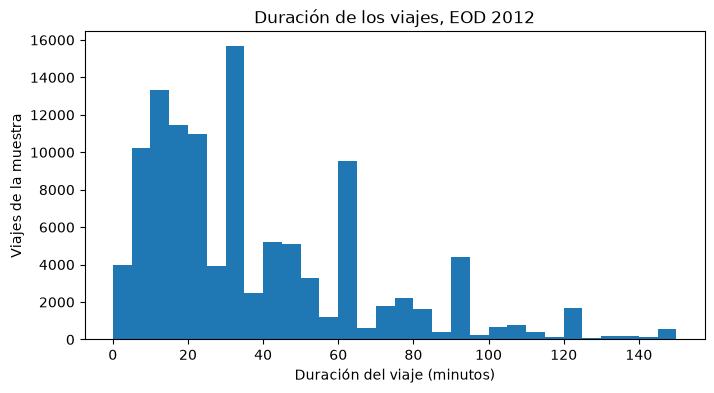

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(viajes["TiempoViaje"].dropna(), bins=30, range=(0, 150))
ax.set_xlabel("Duración del viaje (minutos)")
ax.set_ylabel("Viajes de la muestra")
ax.set_title("Duración de los viajes, EOD 2012")
plt.show()

Dos cosas para mirar: la cola larga hacia la derecha (pocos viajes muy largos) y los peaks en los múltiplos de media hora, porque las personas declaran duraciones redondeadas. En la clase 2 pondremos nombre y número a todo esto: media, mediana, dispersión, forma.

Un ejemplo de variable **discreta**, para completar el mapa de la clase: cuántos viajes hizo cada persona en el día. Se obtiene contando filas por persona, y sus valores son 1, 2, 3..., no cualquier decimal.

In [13]:
viajes_por_persona = viajes.groupby(["Hogar", "Persona"]).size()

# Cuántas personas hicieron 1, 2, 3... viajes (entre quienes viajaron)
viajes_por_persona.value_counts().sort_index().head(8)

1     1331
2    35056
3     2390
4     5199
5      823
6      881
7      241
8      206
Name: count, dtype: int64

## 6. Cruzar variables: promedios por grupo

Lo más interesante aparece al cruzar una cualitativa con una cuantitativa: por ejemplo, la duración de los viajes según la comuna donde parten. El patrón es `groupby` (partir la tabla en grupos) seguido del resumen que se quiera por grupo, aquí la media.

Usamos `viajes_comuna`, la tabla que ya tiene los nombres puestos:

In [14]:
duracion_comuna = (viajes_comuna
    .groupby("Comuna")["TiempoViaje"].mean()
    .sort_values(ascending=False))

# Comunas desde donde parten los viajes más largos, en promedio
duracion_comuna.head(10).round(1)

Comuna
La Pintana          45.2
Santiago            45.1
Quilicura           42.7
Padre Hurtado       42.4
Providencia         40.7
Peñaflor            40.6
Talagante           40.6
Huechuraba          40.0
Estación Central    40.0
Independencia       39.3
Name: TiempoViaje, dtype: float64

Y el otro extremo:

In [15]:
duracion_comuna.tail(10).round(1)

Comuna
Conchalí               32.7
Lampa                  32.6
Lo Prado               31.5
Cerro Navia            30.4
El Bosque              30.2
San Ramón              30.0
La Granja              29.8
San Bernardo           29.0
Pedro Aguirre Cerda    28.0
Buin                   26.4
Name: TiempoViaje, dtype: float64

Aquí sí tiene sentido promediar: `TiempoViaje` es cuantitativa, y la comuna solo define los grupos. Son medias de la muestra, sin ponderar, así que se leen como descripción de los encuestados, no de la ciudad.

Ya tenemos el kit inicial completo: contar (`value_counts`), traducir códigos (`merge`), resumir (`describe`), mirar la forma (histograma) y comparar grupos (`groupby`).

## 7. Ejercicio

La misma encuesta tiene una tabla de personas, en `BASE + "personas.csv"` (mismo separador y mismo decimal), y la tabla de parámetros `BASE + "tablas_parametros/Sexo.csv"` traduce el código de la columna `Sexo`.

1. Abra la tabla de personas y revise `shape`, `head` e `info`.
2. Clasifique cinco de sus columnas según el esquema de la clase: nominal, ordinal, discreta o continua.
3. Traduzca el código de `Sexo` con su tabla de parámetros usando `merge`, y calcule la proporción de hombres y mujeres con `value_counts(normalize=True)`.
4. Elija una variable cuantitativa, resúmala con `describe` y grafique su histograma.
5. Calcule el promedio de esa variable por grupo de otra columna cualitativa, con `groupby`.
6. Anote una pregunta sobre los viajes de Santiago que le gustaría responder con estas tablas: puede ser el germen de su proyecto final.

In [16]:
# Su solución


---

**Próxima clase (jueves 27):** estadística descriptiva: qué miden exactamente la media, la mediana y las medidas de dispersión que hoy aparecieron de pasada, y cuándo usar cada una. Traiga el entorno funcionando; si algo falló hoy, revise la sección de problemas frecuentes de la guía de instalación o escríbanos.